# **Example prospective AWARE 2.0 | Use case 1b**

**Authors:**  [Romain Sacchi](mailto:romain.sacchi@psi.ch)

This notebook checks the prospective AWARE 2.0 method generated for `edges`. It follows the same hydrogen PEM use case as `use case 1 - AWARE 2.0.ipynb`, but evaluates:

- deterministic LCIA scores across SSP scenarios and years;
- stochastic LCIA scores for one selected scenario/year using basin-specific uncertainty distributions.

The prospective method data are based on the 2026 AWARE2.0 prospective characterization-factor paper by Seitfudem, Berger, and Boulay.

## Structure

1. [Import `edges` and set up a Brightway project](#sec_import_edges)
2. [Import or reuse hydrogen production, PEM, LCI](#sec_import_h2)
3. [Select the functional unit and prospective AWARE method](#sec_select_fu)
4. [Inspect the method structure](#sec_inspect_method)
5. [Run deterministic scenario/year checks](#sec_deterministic)
6. [Run stochastic basin-distribution checks](#sec_stochastic)
7. [Optional export](#sec_export)

<a id="sec_import_edges"></a>
# 1. Import `edges` and set up a Brightway project

In [1]:
from pathlib import Path
import json
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bw2data
import bw2io
from edges import EdgeLCIA, get_available_methods, setup_package_logging

setup_package_logging(level=logging.INFO)

13:35:12+0200 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.


In [2]:
PROJECT_NAME = "ecoinvent-3.10-cutoff"
H2_DB_NAME = "h2_pem"
REIMPORT_H2_DB = False
INVENTORY_XLSX = Path("lci-hydrogen-electrolysis-ei310.xlsx")

ACTIVITY_NAME = "hydrogen production, gaseous, 30 bar, from PEM electrolysis, from offshore wind electricity"
ACTIVITY_LOCATION = None

METHOD = ("AWARE 2.0 prospective", "Country", "all", "yearly")
SCENARIOS = ["SSP126", "SSP370", "SSP585"]
YEARS = ["2019", "2024", "2029", "2034", "2039", "2044", "2049"]

STOCHASTIC_SCENARIO = "SSP585"
STOCHASTIC_YEAR = "2049"
STOCHASTIC_ITERATIONS = 1_000
RANDOM_SEED = 42

In [3]:
bw2data.projects.set_current("ecoinvent-3.10-cutoff")
print(f"Current Brightway project: {bw2data.projects.current}")
print("Available databases:")
list(bw2data.databases)

Current Brightway project: ecoinvent-3.10-cutoff
Available databases:


['ecoinvent-3.10-biosphere',
 'ecoinvent-3.10-cutoff',
 'premise_metals_ei310_cutoff_20260604T180603',
 'h2_pem']

<a id="sec_import_h2"></a>
# 2. Import or reuse hydrogen production, PEM, LCI

The default is to reuse `h2_pem` if it already exists. Set `REIMPORT_H2_DB = True` in the configuration cell to delete and recreate it from `lci-hydrogen-electrolysis-ei310.xlsx`.

In [16]:
if H2_DB_NAME in bw2data.databases and REIMPORT_H2_DB:
    del bw2data.databases[H2_DB_NAME]

if not INVENTORY_XLSX.exists():
    raise FileNotFoundError(f"Inventory workbook not found: {INVENTORY_XLSX.resolve()}")

importer = bw2io.ExcelImporter(str(INVENTORY_XLSX))
importer.apply_strategies()
importer.match_database(fields=["name", "reference product", "location"])

matched_background = False
for db_name in MATCH_DATABASE_CANDIDATES:
    if db_name in bw2data.databases:
        importer.match_database(db_name, fields=["name", "reference product", "location"])
        print(f"Matched foreground against background database: {db_name}")
        matched_background = True
        break

if not matched_background:
    print("No configured background database name was found; check unlinked exchanges below.")

importer.match_database("ecoinvent-3.10-biosphere", fields=["name", "categories"])
importer.statistics()
#importer.drop_unlinked(i_am_reckless=True)

if len(list(importer.unlinked)) != 0:
    print(list(importer.unlinked))
    raise RuntimeError("The hydrogen inventory still has unlinked exchanges after matching.")

importer.write_database()


Extracted 1 worksheets in 0.06 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 14 strategies in 0.14 seconds
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Matched foreground against background database: ecoinvent-3.10-cutoff
Applying strategy: link_iterable_by_fields
Graph statistics for `h2_pem` importer:
11 graph nodes:
	None: 11
214

100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 336.05it/s]

13:06:48+0200 [info     ] Vacuuming database            


Created database: h2_pem


In [17]:
classifications = {
    "hydrogen production, gaseous, 30 bar, from PEM electrolysis, from grid electricity": ("CPC", "34210"),
    "hydrogen production, gaseous, 30 bar, from PEM electrolysis, from solar photovoltaic electricity": ("CPC", "34210"),
    "hydrogen production, gaseous, 30 bar, from PEM electrolysis, from onshore wind electricity": ("CPC", "34210"),
    "hydrogen production, gaseous, 30 bar, from PEM electrolysis, from offshore wind electricity": ("CPC", "34210"),
    "hydrogen production, gaseous, 30 bar, from PEM electrolysis, from geothermal electricity": ("CPC", "34210"),
    "electrolyzer production, 1MWe, PEM, Stack": ("CPC", "4220:Construction of utility projects"),
    "treatment of electrolyzer stack, 1MWe, PEM": ("CPC", "3830"),
    "electrolyzer production, 1MWe, PEM, Balance of Plant": ("CPC", "4220:Construction of utility projects"),
    "treatment of electrolyzer balance of plant, 1MWe, PEM": ("CPC", "3830"),
    "platinum group metal, extraction and refinery operations": ("CPC", "2420"),
    "deionized water production, via reverse osmosis, from brackish water": ("CPC", "34210"),
}

for ds in bw2data.Database(H2_DB_NAME):
    if ds["name"] in classifications:
        ds["classifications"] = [classifications[ds["name"]]]
        ds.save()

print("Assigned CPC classifications to foreground activities where available.")

Assigned CPC classifications to foreground activities where available.


<a id="sec_select_fu"></a>
# 3. Select the functional unit and prospective AWARE method

In [4]:
candidates = [
    activity
    for activity in bw2data.Database(H2_DB_NAME)
    if activity["name"] == ACTIVITY_NAME
    and (ACTIVITY_LOCATION is None or activity.get("location") == ACTIVITY_LOCATION)
]

if len(candidates) != 1:
    pd.DataFrame(
        [
            {
                "name": activity.get("name"),
                "reference product": activity.get("reference product"),
                "location": activity.get("location"),
                "code": activity.get("code"),
            }
            for activity in candidates
        ]
    )
    raise ValueError(f"Expected exactly one functional-unit activity, found {len(candidates)}.")

act = candidates[0]
act

'hydrogen production, gaseous, 30 bar, from PEM electrolysis, from offshore wind electricity' (kilogram, FR, None)

In [5]:
available_methods = get_available_methods()
if METHOD not in available_methods:
    raise ValueError(f"Method {METHOD!r} was not found in get_available_methods().")

METHOD

('AWARE 2.0 prospective', 'Country', 'all', 'yearly')

<a id="sec_inspect_method"></a>
# 4. Inspect the method structure

The prospective method keeps numeric baseline `value` and `weight` fields, and uses `value_expression` and `weight_expression` to select scenario/year-specific values.

In [6]:
method_path = Path("../../edges/data/AWARE 2.0 prospective_Country_all_yearly.json")
with method_path.open("r") as f:
    method_data = json.load(f)

print(method_data["name"])
print("version:", method_data["version"])
print("scenarios:", list(method_data["parameters"]))
print("uncertainty refs:", len(method_data["uncertainties"]))
print("exchange rows:", len(method_data["exchanges"]))
method_data["exchanges"][0]

ecoinvent 3.10/3.11 - AWARE 2.0 prospective_Country_all_yearly
version: 1.0.0
scenarios: ['SSP126', 'SSP370', 'SSP585']
uncertainty refs: 515
exchange rows: 6760


{'supplier': {'name': 'Water', 'categories': ['water'], 'matrix': 'biosphere'},
 'consumer': {'location': 'AD',
  'matrix': 'technosphere',
  'classifications': {'CPC': ['01']}},
 'value': -80.5,
 'value_expression': '-cf_irri_ad',
 'weight': 672409.426809,
 'weight_expression': 'wt_irri_ad'}

In [7]:
sample_parameter = next(iter(method_data["parameters"][SCENARIOS[0]]))
print("Example parameter:", sample_parameter)
method_data["parameters"][SCENARIOS[0]][sample_parameter]

Example parameter: cf_irri_ad


{'2019': 80.5,
 '2024': 81.9,
 '2029': 84.9,
 '2034': 85.0,
 '2039': 86.2,
 '2044': 93.7,
 '2049': 93.9}

<a id="sec_deterministic"></a>
# 5. Run deterministic scenario/year checks

This run does not sample uncertainty. It evaluates the country-average `value_expression` and `weight_expression` for each scenario/year pair.

In [8]:
det_lca = EdgeLCIA(
    demand={act: 1},
    method=METHOD,
    use_distributions=False,
)

det_lca.lci()
det_lca.apply_strategies()
det_lca.statistics()

/opt/homebrew/Caskroom/miniforge/base/envs/edges/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 5.51e+12)
  warnings.warn(msg, UmfpackWarning)


Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]
+----------------------+---------------------------------------------+
|       Activity       |  hydrogen production, gaseous, 30 bar, from |
|                      |     PEM electrolysis, from offshore wind    |
|                      |                 electricity                 |
|     Method name      | ('AWARE 2.0 prospective', 'Country', 'all', |
|                      |                  'yearly')                  |
|         Unit         |            m3 deprived water-eq.            |
|      Data file       |   AWARE 2.0 prospective_Country_all_yearly  |
|    CFs in method     |                     6760                    |
|       CFs used       |                     8900                    |
|   Unique CFs used    |                     355                     |
|  Exc. characterized  |               

In [9]:
deterministic_records = []

for scenario in SCENARIOS:
    for year in YEARS:
        print(scenario, year)
        det_lca.evaluate_cfs(scenario=scenario, scenario_idx=year)
        det_lca.lcia()
        deterministic_records.append(
            {
                "scenario": scenario,
                "year": int(year),
                "score": float(det_lca.score),
                "matched_cf_entries": len(det_lca.scenario_cfs),
            }
        )

deterministic_results = pd.DataFrame(deterministic_records)
deterministic_results

SSP126 2019
SSP126 2024
SSP126 2029
SSP126 2034
SSP126 2039
SSP126 2044
SSP126 2049
SSP370 2019
SSP370 2024
SSP370 2029
SSP370 2034
SSP370 2039
SSP370 2044
SSP370 2049
SSP585 2019
SSP585 2024
SSP585 2029
SSP585 2034
SSP585 2039
SSP585 2044
SSP585 2049


,scenario,year,score,matched_cf_entries
0,SSP126,2019,0.725361,8900
1,SSP126,2024,0.728999,8900
2,SSP126,2029,0.742794,8900
3,SSP126,2034,0.746062,8900
4,SSP126,2039,0.759558,8900
5,SSP126,2044,0.797268,8900
6,SSP126,2049,0.821296,8900
7,SSP370,2019,0.725361,8900
8,SSP370,2024,0.730359,8900
9,SSP370,2029,0.737919,8900


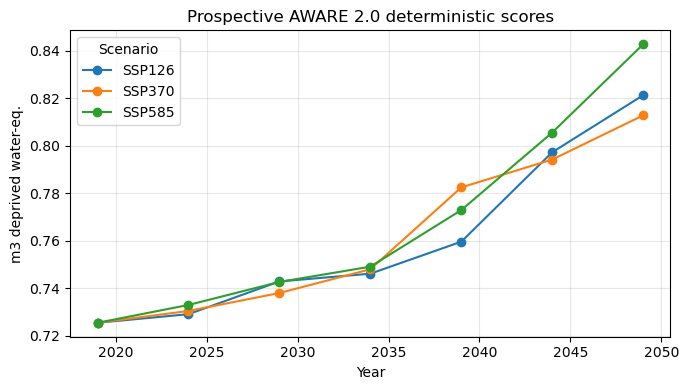

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for scenario, group in deterministic_results.groupby("scenario"):
    group = group.sort_values("year")
    ax.plot(group["year"], group["score"], marker="o", label=scenario)

ax.set_xlabel("Year")
ax.set_ylabel(method_data["unit"])
ax.set_title("Prospective AWARE 2.0 deterministic scores")
ax.legend(title="Scenario")
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [11]:
deterministic_cf_table = det_lca.generate_cf_table(include_unmatched=False)
deterministic_cf_table.head()

,supplier matrix,direction,supplier name,supplier categories,consumer name,consumer reference product,consumer location,consumer cpc,consumer ecospold01categories,consumer isic rev.4 ecoinvent,amount,CF,impact
0,biosphere,biosphere-technosphere,"Water, unspecified natural origin","(natural resource, in ground)",citric acid production,maize starch,CN,23220: Starches; inulin; wheat gluten; dextrin...,None,2011:Manufacture of basic chemicals,5.304078e-16,6.18,3.277920e-15
1,biosphere,biosphere-technosphere,"Water, unspecified natural origin","(natural resource, in ground)",urea production,urea,CN,34611: Urea,None,2012:Manufacture of fertilizers and nitrogen c...,6.551305e-08,6.18,4.048706e-07
2,biosphere,biosphere-technosphere,"Water, unspecified natural origin","(natural resource, in ground)",soy-based resin production,"polyester resin, unsaturated",US,"34740: Polyacetals, other polyethers and epoxi...",None,2013:Manufacture of plastics and synthetic rub...,1.389985e-11,12.20,1.695782e-10
3,biosphere,biosphere-technosphere,"Water, unspecified natural origin","(natural resource, in ground)",citric acid production,citric acid,CN,"34140: Carboxylic acids and their anhydrides, ...",None,2011:Manufacture of basic chemicals,3.600265e-11,6.18,2.224964e-10
4,biosphere,biosphere-technosphere,"Water, unspecified natural origin","(natural resource, in ground)",burnt shale production,burnt shale,DE,12030: Bituminous or oil shale and tar sands,None,2399:Manufacture of other non-metallic mineral...,1.008969e-11,2.37,2.391256e-11


<a id="sec_stochastic"></a>
# 6. Run stochastic basin-distribution checks

This run samples basin-specific CFs and basin weights for one selected scenario/year. Increase `STOCHASTIC_ITERATIONS` after the notebook runs end-to-end.

In [12]:
stoch_lca = EdgeLCIA(
    demand={act: 1},
    method=METHOD,
    scenario=STOCHASTIC_SCENARIO,
    use_distributions=True,
    iterations=STOCHASTIC_ITERATIONS,
    random_seed=RANDOM_SEED,
)

stoch_lca.lci()
stoch_lca.apply_strategies()
stoch_lca.evaluate_cfs(scenario=STOCHASTIC_SCENARIO, scenario_idx=STOCHASTIC_YEAR)
stoch_lca.lcia()

/opt/homebrew/Caskroom/miniforge/base/envs/edges/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 5.51e+12)
  warnings.warn(msg, UmfpackWarning)


Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]


In [13]:
stochastic_scores = np.asarray(stoch_lca.score, dtype=float).reshape(-1)
stochastic_summary = pd.Series(stochastic_scores).describe(
    percentiles=[0.025, 0.05, 0.5, 0.95, 0.975]
).to_frame("score")
stochastic_summary

,score
count,1000.000000
mean,0.862702
std,0.247130
min,0.247048
2.5%,0.406252
5%,0.453780
50%,0.860268
95%,1.269874
97.5%,1.344578
max,1.616708


In [14]:
deterministic_reference = deterministic_results.loc[
    (deterministic_results["scenario"] == STOCHASTIC_SCENARIO)
    & (deterministic_results["year"] == int(STOCHASTIC_YEAR)),
    "score",
]

deterministic_reference_score = float(deterministic_reference.iloc[0])
comparison = pd.DataFrame(
    [
        {"metric": "deterministic", "score": deterministic_reference_score},
        {"metric": "stochastic mean", "score": float(stochastic_scores.mean())},
        {"metric": "stochastic median", "score": float(np.median(stochastic_scores))},
    ]
)
comparison

,metric,score
0,deterministic,0.842779
1,stochastic mean,0.862702
2,stochastic median,0.860268


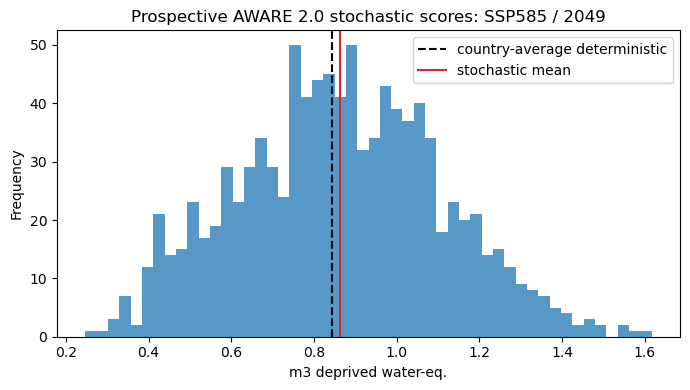

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(stochastic_scores, bins=50, alpha=0.75)
ax.axvline(deterministic_reference_score, color="black", linestyle="--", label="country-average deterministic")
ax.axvline(stochastic_scores.mean(), color="tab:red", linestyle="-", label="stochastic mean")
ax.set_xlabel(method_data["unit"])
ax.set_ylabel("Frequency")
ax.set_title(f"Prospective AWARE 2.0 stochastic scores: {STOCHASTIC_SCENARIO} / {STOCHASTIC_YEAR}")
ax.legend()
plt.tight_layout()

In [ ]:
stochastic_cf_table = stoch_lca.generate_cf_table(include_unmatched=False)
stochastic_cf_table.head()

<a id="sec_export"></a>
# 7. Optional export

In [ ]:
EXPORT_RESULTS = False
OUTPUT_XLSX = Path("prospective_AWARE_results.xlsx")

if EXPORT_RESULTS:
    with pd.ExcelWriter(OUTPUT_XLSX) as writer:
        deterministic_results.to_excel(writer, sheet_name="deterministic", index=False)
        stochastic_summary.to_excel(writer, sheet_name="stochastic_summary")
        comparison.to_excel(writer, sheet_name="comparison", index=False)
        deterministic_cf_table.head(10_000).to_excel(writer, sheet_name="det_cf_table", index=False)
        stochastic_cf_table.head(10_000).to_excel(writer, sheet_name="stoch_cf_table", index=False)
    print(f"Wrote {OUTPUT_XLSX.resolve()}")

## Notes after running

- Check whether scenario trends look plausible before increasing stochastic iterations.
- If stochastic and deterministic central tendencies diverge strongly, inspect the basin distributions and country weights for the main contributing exchanges.
- If `generate_cf_table()` is large, filter it by supplier/consumer contribution before exporting.